In [1]:
# ============================================================
# 0) IMPORTS E CONFIGURAÇÕES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import shapiro, ttest_ind, mannwhitneyu, f_oneway, kruskal
from scipy.stats import chi2_contingency, fisher_exact

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# caminho do ficheiro
file_path = "data.xlsx"

# ============================================================
# 1) CARREGAR DADOS
# ============================================================

df_total = pd.read_excel(file_path, sheet_name="Seguimento prévio")
df = pd.read_excel(file_path, sheet_name="Recolha_de_Dados")

# limpar nomes das colunas
df_total.columns = [str(c).strip() for c in df_total.columns]
df.columns = [str(c).strip() for c in df.columns]

# renomear a primeira coluna vazia para "Nome", se existir
if "" in df.columns:
    df = df.rename(columns={"": "Nome"})

print("Folha total internamentos:", df_total.shape)
print("Folha principal:", df.shape)
print("\nColunas da folha principal:")
print(df.columns.tolist())

Folha total internamentos: (43, 3)
Folha principal: (38, 23)

Colunas da folha principal:
['Nome', 'nº processo', 'Data de nascimento', 'Idade', 'Sexo', 'Doença crónica PRÉVIA', 'Doença psiquiátrica prévia', 'Qual', 'Data de admissao na UCIPed', 'Data_alta_UCIPed', 'Tempo_total_UCIP_dias', 'Diagnóstico_admissao_principal', 'Categoria_diagnóstico', 'Ventilação', 'Dias de ventilação', 'Sedo-analgia', 'Dias de sedoanalgesia', 'Motivo de apoio psicológico', 'Unnamed: 18', 'Medicação psiquiátrica iniciada', 'Alta UCIP destino', 'Seguimento psic após alta', 'Duração do seguimento']


In [3]:
# ============================================================
# 2) PADRONIZAÇÃO / LIMPEZA
# ============================================================

# converter datas
date_cols = ["Data de nascimento", "Data de admissao na UCIPed", "Data_alta_UCIPed"]
for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

# converter numéricas
numeric_cols = ["Idade", "Tempo_total_UCIP_dias", "Dias de ventilação", "Dias de sedoanalgesia"]
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# padronizar respostas sim/não
def normalize_sim_nao(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip().lower()
    if x in ["sim", "s", "yes", "y"]:
        return "Sim"
    if x in ["não", "nao", "n", "no"]:
        return "Não"
    return str(x).strip()

sim_nao_cols = [
    "Doença psiquiátrica prévia",
    "Ventilação",
    "Sedo-analgia",
    "Medicação psiquiátrica iniciada",
    "Seguimento psic após alta"
]

for col in sim_nao_cols:
    if col in df.columns:
        df[col] = df[col].apply(normalize_sim_nao)

# padronizar sexo
if "Sexo" in df.columns:
    df["Sexo"] = df["Sexo"].astype(str).str.strip().str.capitalize()

# doença crónica prévia: transformar em Sim/Não
# regra:
# - "não"/"nao" -> Não
# - qualquer outro texto preenchido -> Sim
if "Doença crónica PRÉVIA" in df.columns:
    def doença_cronica_bin(x):
        if pd.isna(x):
            return np.nan
        x2 = str(x).strip().lower()
        if x2 in ["não", "nao", "não.", "nao."]:
            return "Não"
        return "Sim"
    df["Doença crónica prévia_bin"] = df["Doença crónica PRÉVIA"].apply(doença_cronica_bin)

# intervenção realizada
# No teu ficheiro, a coluna "Unnamed: 18" parece corresponder ao tipo de intervenção
if "Unnamed: 18" in df.columns:
    df = df.rename(columns={"Unnamed: 18": "Tipo de intervenção realizada"})

In [4]:
# ============================================================
# 3) FUNÇÕES AUXILIARES
# ============================================================

def freq_table(series, dropna=False):
    s = series.copy()
    counts = s.value_counts(dropna=dropna)
    perc = s.value_counts(dropna=dropna, normalize=True) * 100
    out = pd.DataFrame({
        "n": counts,
        "%": perc.round(1)
    })
    return out

def continuous_summary(series, name="Variável"):
    s = pd.to_numeric(series, errors="coerce").dropna()
    result = {"variável": name, "n": len(s)}
    
    if len(s) < 3:
        result.update({
            "normalidade_p": np.nan,
            "distribuição": "Amostra insuficiente",
            "resumo": f"mediana={s.median():.2f}; IIQ=({s.quantile(0.25):.2f}-{s.quantile(0.75):.2f})" if len(s) > 0 else "Sem dados"
        })
        return result
    
    p_shapiro = shapiro(s).pvalue if len(s) <= 5000 else np.nan
    normal = p_shapiro > 0.05 if not np.isnan(p_shapiro) else False
    
    if normal:
        resumo = f"{s.mean():.2f} ± {s.std(ddof=1):.2f}"
        dist = "Normal"
    else:
        resumo = f"{s.median():.2f} ({s.quantile(0.25):.2f}-{s.quantile(0.75):.2f})"
        dist = "Não normal"
    
    result.update({
        "normalidade_p": round(p_shapiro, 4) if not np.isnan(p_shapiro) else np.nan,
        "distribuição": dist,
        "resumo": resumo,
        "mín": round(s.min(), 2),
        "máx": round(s.max(), 2)
    })
    return result

def plot_bar(series, title, xlabel="", ylabel="Frequência", rotate=0, order=None):
    s = series.dropna()
    plt.figure(figsize=(10, 6))
    
    if order is None:
        order = s.value_counts().index
    
    sns.countplot(x=s, order=order)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(rotation=rotate, ha="right")
    plt.tight_layout()
    plt.show()

def plot_box(series, title, ylabel=""):
    s = pd.to_numeric(series, errors="coerce").dropna()
    plt.figure(figsize=(8, 5))
    sns.boxplot(y=s)
    plt.title(title)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()

def plot_grouped_bar(data, group_col, category_col, title, rotate=0):
    tmp = data[[group_col, category_col]].dropna()
    plt.figure(figsize=(10, 6))
    sns.countplot(data=tmp, x=category_col, hue=group_col)
    plt.title(title)
    plt.xlabel(category_col)
    plt.ylabel("Frequência")
    plt.xticks(rotation=rotate, ha="right")
    plt.tight_layout()
    plt.show()

def compare_continuous_2groups(data, value_col, group_col):
    tmp = data[[value_col, group_col]].dropna()
    groups = tmp[group_col].unique()
    
    if len(groups) != 2:
        return {"teste": "N/A", "p": np.nan, "nota": "Não há exatamente 2 grupos"}
    
    g1 = pd.to_numeric(tmp[tmp[group_col] == groups[0]][value_col], errors="coerce").dropna()
    g2 = pd.to_numeric(tmp[tmp[group_col] == groups[1]][value_col], errors="coerce").dropna()
    
    if len(g1) < 2 or len(g2) < 2:
        return {"teste": "N/A", "p": np.nan, "nota": "Grupos com poucos dados"}
    
    p1 = shapiro(g1).pvalue if len(g1) >= 3 else 0
    p2 = shapiro(g2).pvalue if len(g2) >= 3 else 0
    
    if p1 > 0.05 and p2 > 0.05:
        stat, p = ttest_ind(g1, g2, equal_var=False, nan_policy="omit")
        test_name = "t de Student (Welch)"
    else:
        stat, p = mannwhitneyu(g1, g2, alternative="two-sided")
        test_name = "Mann-Whitney"
    
    return {"teste": test_name, "p": round(p, 4)}

def compare_categorical_2groups(data, cat_col, group_col):
    tmp = data[[cat_col, group_col]].dropna()
    table = pd.crosstab(tmp[cat_col], tmp[group_col])
    
    if table.shape[1] != 2:
        return {"teste": "Qui-quadrado", "p": np.nan, "nota": "Não há exatamente 2 grupos"}
    
    # fisher apenas para 2x2
    if table.shape == (2, 2):
        _, p = fisher_exact(table)
        return {"teste": "Exato de Fisher", "p": round(p, 4)}
    else:
        chi2, p, dof, expected = chi2_contingency(table)
        return {"teste": "Qui-quadrado", "p": round(p, 4)}

def compare_continuous_3groups(data, value_col, group_col):
    tmp = data[[value_col, group_col]].dropna()
    groups = sorted(tmp[group_col].dropna().unique())
    
    if len(groups) < 3:
        return {"teste": "N/A", "p": np.nan, "nota": "Menos de 3 grupos"}
    
    arrays = [pd.to_numeric(tmp[tmp[group_col] == g][value_col], errors="coerce").dropna() for g in groups]
    arrays = [a for a in arrays if len(a) > 0]
    
    if len(arrays) < 3:
        return {"teste": "N/A", "p": np.nan, "nota": "Menos de 3 grupos com dados"}
    
    all_normal = True
    for a in arrays:
        if len(a) < 3:
            all_normal = False
            break
        if shapiro(a).pvalue <= 0.05:
            all_normal = False
            break
    
    if all_normal:
        stat, p = f_oneway(*arrays)
        return {"teste": "ANOVA", "p": round(p, 4)}
    else:
        stat, p = kruskal(*arrays)
        return {"teste": "Kruskal-Wallis", "p": round(p, 4)}

def compare_categorical_3groups(data, cat_col, group_col):
    tmp = data[[cat_col, group_col]].dropna()
    table = pd.crosstab(tmp[cat_col], tmp[group_col])
    if table.shape[1] < 3:
        return {"teste": "N/A", "p": np.nan, "nota": "Menos de 3 grupos"}
    chi2, p, dof, expected = chi2_contingency(table)
    return {"teste": "Qui-quadrado", "p": round(p, 4)}

def significance_label(p):
    if pd.isna(p):
        return ""
    return "Significativo" if p < 0.05 else "Não significativo"

In [5]:
# ============================================================
# 4) MAPEAMENTO DAS VARIÁVEIS DO PLANO PARA O DATASET
# ============================================================

# ajusta aqui se quiseres trocar alguma coluna
vars_map = {
    "idade": "Idade",
    "sexo": "Sexo",
    "doenca_cronica": "Doença crónica prévia_bin",
    "antecedente_psiquiatrico": "Doença psiquiátrica prévia",
    "duracao_internamento": "Tempo_total_UCIP_dias",
    "motivo_internamento": "Categoria_diagnóstico",
    "ventilacao": "Ventilação",
    "duracao_ventilacao": "Dias de ventilação",
    "duracao_sedacao": "Dias de sedoanalgesia",
    "motivo_apoio_psicologico": "Motivo de apoio psicológico",
    "intervencao": "Tipo de intervenção realizada",
    "seguimento": "Seguimento psic após alta",
    "duracao_seguimento": "Duração do seguimento",
    "grupo_clinico_base": "Categoria_diagnóstico"
}

# variáveis ausentes no dataset:
# - diagnóstico psiquiátrico (não há coluna clara)
# - tipo de seguimento (não há coluna clara)
#
# se quiseres usar alguma coluna como aproximação, muda aqui:
diagnostico_psiquiatrico_col = None
tipo_seguimento_col = None

In [6]:
# ============================================================
# 5) CRIAÇÃO DOS GRUPOS CLÍNICOS A/B/C
# ============================================================

# Definição:
# Grupo A: Antecedente psiquiátrico + internamento por causa psiquiátrica
# Grupo B: Antecedente psiquiátrico + internamento por causa médica
# Grupo C: Sem antecedente psiquiátrico

# Como não existe uma categoria explícita "psiquiátrica" no motivo de internamento,
# vamos considerar "Acidentes e causas externas" + motivos de apoio psicológico como
# informação auxiliar, mas a decisão principal será:
# - se antecedente psiquiátrico = Não -> Grupo C
# - se antecedente psiquiátrico = Sim:
#      se o motivo de apoio psicológico mencionar suicídio / ideação / ansiedade / agitação etc.
#      e o contexto parecer psiquiátrico, classificar como Grupo A
#      caso contrário, Grupo B
#
# Esta parte é exploratória e pode ser ajustada.

def define_grupo(row):
    ant = row.get("Doença psiquiátrica prévia", np.nan)
    motivo = str(row.get("Motivo de apoio psicológico", "")).lower()
    categoria = str(row.get("Categoria_diagnóstico", "")).lower()
    
    if ant == "Não":
        return "C"
    
    if ant == "Sim":
        palavras_psiq = [
            "suic", "ideação", "ideacao", "ansiedade", "agitação", "agitacao",
            "humor", "delirio", "comportamento", "heteroagress", "insónia", "insonia"
        ]
        
        if any(p in motivo for p in palavras_psiq):
            return "A"
        else:
            return "B"
    
    return np.nan

df["Grupo clínico"] = df.apply(define_grupo, axis=1)

print(freq_table(df["Grupo clínico"]))

                n     %
Grupo clínico          
C              24  63.2
A               8  21.1
B               6  15.8


=== 1. Caracterização Global da População da UCIP ===
Total de internamentos no período: 43
Número de doentes avaliados pela pedopsiquiatria: 38
Proporção avaliada: 88.4%


,Grupo,n,%
0,Total internamentos UCIP,43,100.0
1,Avaliados por pedopsiquiatria,38,88.4


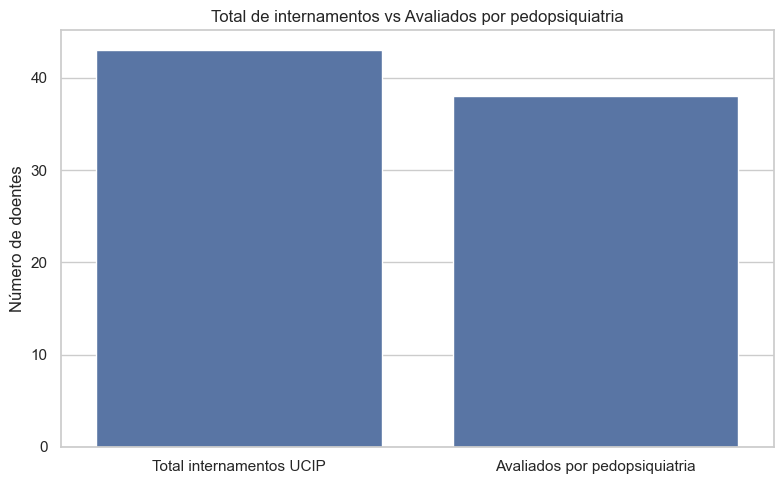


Fluxograma simples:
Internamentos UCIP no período (n=43)
└── Avaliados por pedopsiquiatria (n=38, 88.4%)


In [7]:
# ============================================================
# 6) 1. CARACTERIZAÇÃO GLOBAL DA POPULAÇÃO DA UCIP
# ============================================================

n_total_internamentos = df_total.shape[0]
n_avaliados_psiq = df.shape[0]
perc_avaliados = (n_avaliados_psiq / n_total_internamentos) * 100

print("=== 1. Caracterização Global da População da UCIP ===")
print(f"Total de internamentos no período: {n_total_internamentos}")
print(f"Número de doentes avaliados pela pedopsiquiatria: {n_avaliados_psiq}")
print(f"Proporção avaliada: {perc_avaliados:.1f}%")

# tabela resumo
tabela_global = pd.DataFrame({
    "Grupo": ["Total internamentos UCIP", "Avaliados por pedopsiquiatria"],
    "n": [n_total_internamentos, n_avaliados_psiq],
    "%": [100.0, round(perc_avaliados, 1)]
})
display(tabela_global)

# gráfico barras
plt.figure(figsize=(8,5))
sns.barplot(data=tabela_global, x="Grupo", y="n")
plt.title("Total de internamentos vs Avaliados por pedopsiquiatria")
plt.ylabel("Número de doentes")
plt.xlabel("")
plt.tight_layout()
plt.show()

# fluxograma simples em texto
print("\nFluxograma simples:")
print(f"Internamentos UCIP no período (n={n_total_internamentos})")
print(f"└── Avaliados por pedopsiquiatria (n={n_avaliados_psiq}, {perc_avaliados:.1f}%)")

In [8]:
# ============================================================
# 7) 2. CARACTERIZAÇÃO DA AMOSTRA AVALIADA PELA PEDOPSIQUIATRIA
# ============================================================

print("=== 2. Caracterização da Amostra Avaliada ===")
print(f"Tamanho da amostra: n = {df.shape[0]}")

=== 2. Caracterização da Amostra Avaliada ===
Tamanho da amostra: n = 38


=== 2.1 Sociodemográfica ===


,variável,n,normalidade_p,distribuição,resumo,mín,máx
0,Idade,38,0.0002,Não normal,14.00 (11.00-16.00),2,17


,n,%
Sexo,,
Feminino,22,57.9
Masculino,16,42.1


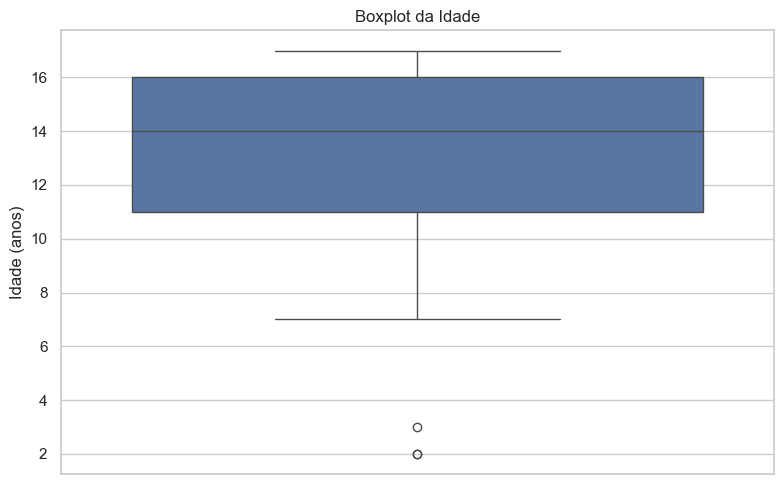

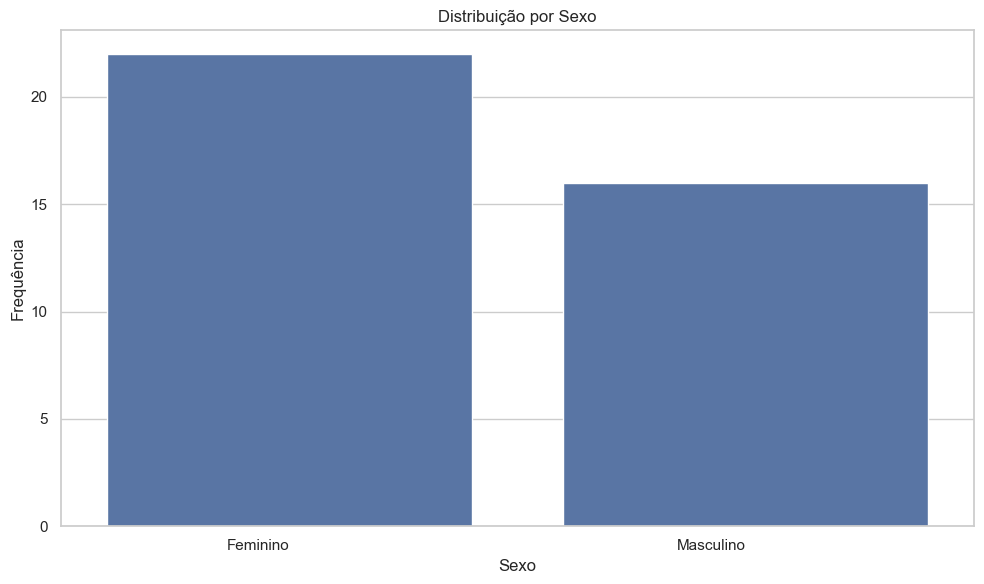

In [9]:
# ============================================================
# 7.1) 2.1 CARACTERIZAÇÃO SOCIODEMOGRÁFICA
# ============================================================

print("=== 2.1 Sociodemográfica ===")

# idade
idade_summary = continuous_summary(df[vars_map["idade"]], "Idade")
display(pd.DataFrame([idade_summary]))

# sexo
sexo_table = freq_table(df[vars_map["sexo"]])
display(sexo_table)

# gráficos
plot_box(df[vars_map["idade"]], "Boxplot da Idade", ylabel="Idade (anos)")
plot_bar(df[vars_map["sexo"]], "Distribuição por Sexo", xlabel="Sexo")

=== 2.2 Caracterização Clínica Prévia ===


,n,%
Doença psiquiátrica prévia,,
Não,24,63.2
Sim,14,36.8


,n,%
Doença crónica prévia_bin,,
Sim,20,52.6
Não,18,47.4


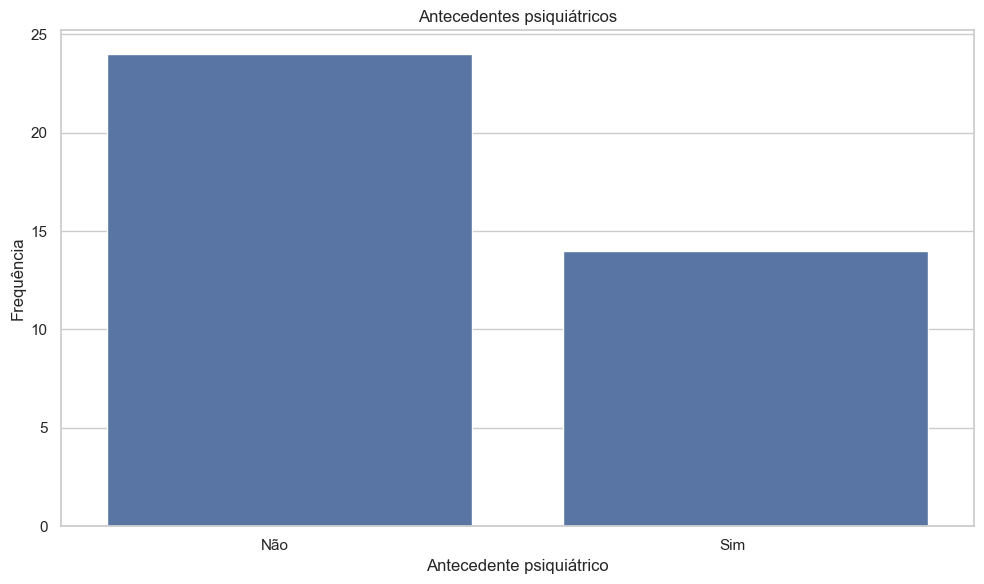

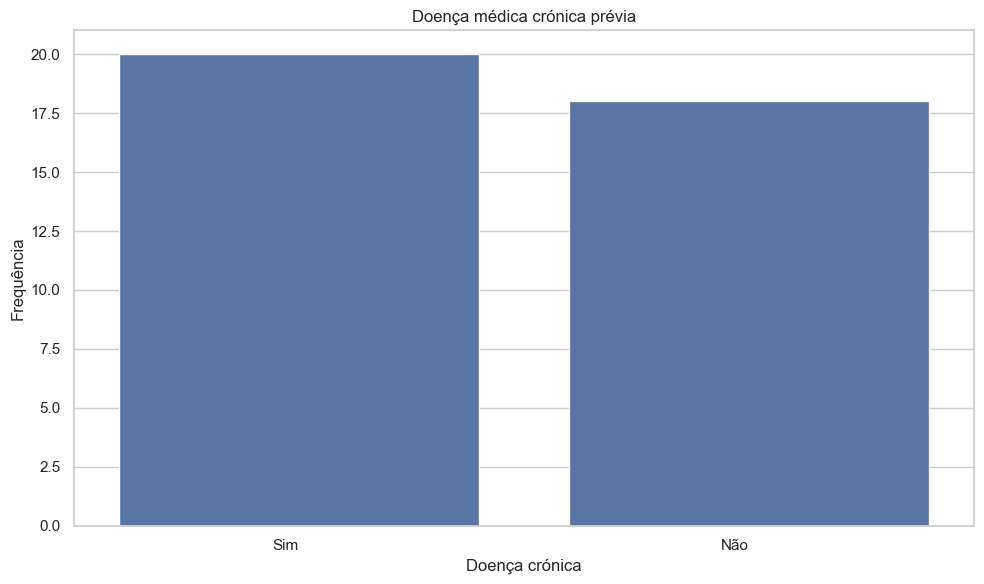

In [10]:
# ============================================================
# 7.2) 2.2 CARACTERIZAÇÃO CLÍNICA PRÉVIA
# ============================================================

print("=== 2.2 Caracterização Clínica Prévia ===")

# antecedente psiquiátrico
ant_psiq_table = freq_table(df[vars_map["antecedente_psiquiatrico"]])
display(ant_psiq_table)

# doença crónica
doenca_cronica_table = freq_table(df[vars_map["doenca_cronica"]])
display(doenca_cronica_table)

# gráficos
plot_bar(df[vars_map["antecedente_psiquiatrico"]], "Antecedentes psiquiátricos", xlabel="Antecedente psiquiátrico")
plot_bar(df[vars_map["doenca_cronica"]], "Doença médica crónica prévia", xlabel="Doença crónica")

=== 2.3 Caracterização do Internamento na UCIP ===


,n,%
Categoria_diagnóstico,,
Trauma,15,39.5
acidentes e causas externas,7,18.4
Neurológico,5,13.2
Respiratório,5,13.2
Infeccioso/Sepsis,3,7.9
Cardíaco,1,2.6
outro,1,2.6
Outro,1,2.6


,variável,n,normalidade_p,distribuição,resumo,mín,máx
0,Duração do internamento,38,0.0,Não normal,5.50 (3.00-14.25),0,182


,n,%
Ventilação,,
Sim,27,71.1
Não,11,28.9


,variável,n,normalidade_p,distribuição,resumo,mín,máx
0,Duração da ventilação,37,0.0,Não normal,2.00 (0.00-12.00),0.0,85.0


,variável,n,normalidade_p,distribuição,resumo,mín,máx
0,Duração da sedoanalgesia,38,0.0,Não normal,5.00 (2.25-17.25),0,152


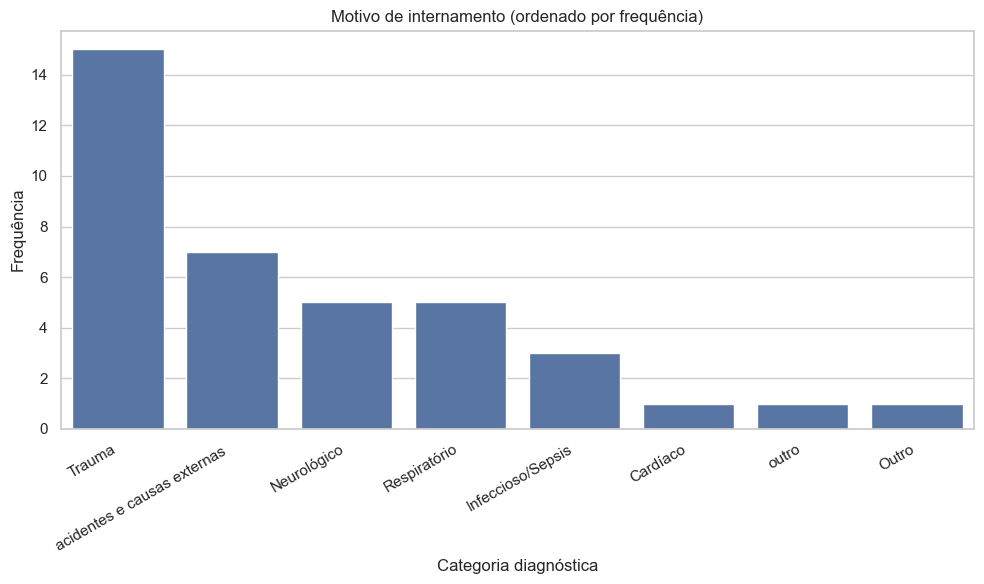

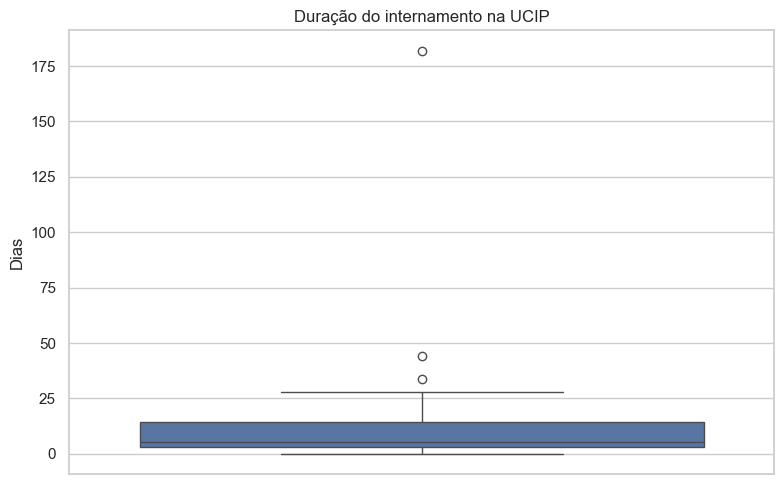

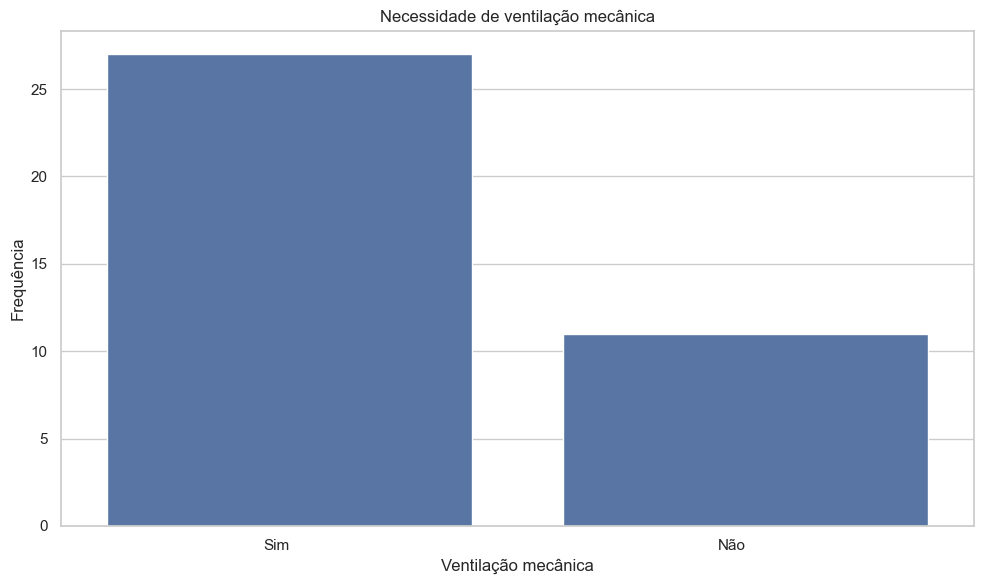

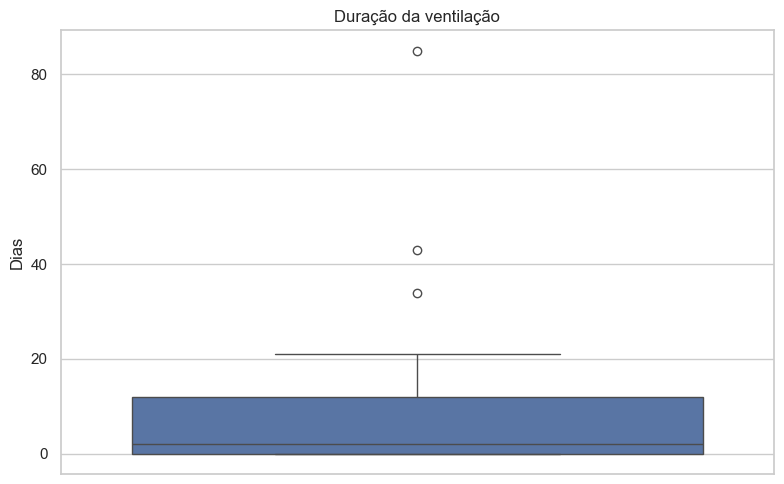

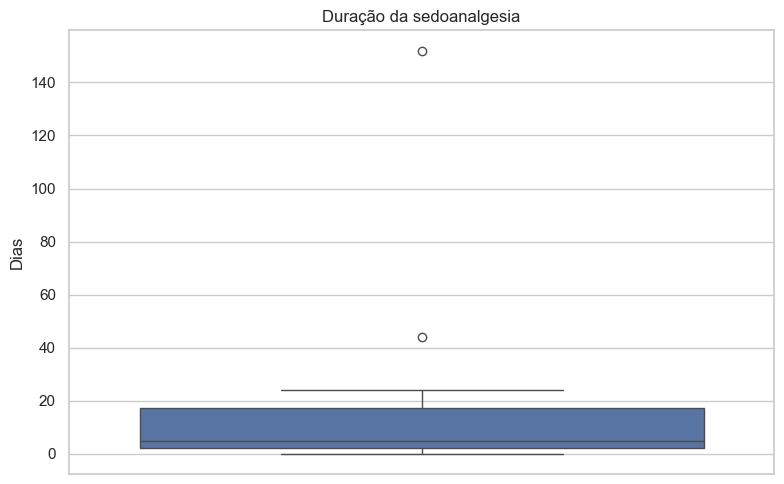

In [11]:
# ============================================================
# 7.3) 2.3 CARACTERIZAÇÃO DO INTERNAMENTO NA UCIP
# ============================================================

print("=== 2.3 Caracterização do Internamento na UCIP ===")

# motivo de internamento
motivo_table = freq_table(df[vars_map["motivo_internamento"]])
display(motivo_table)

# duração do internamento
internamento_summary = continuous_summary(df[vars_map["duracao_internamento"]], "Duração do internamento")
display(pd.DataFrame([internamento_summary]))

# ventilação mecânica
vent_table = freq_table(df[vars_map["ventilacao"]])
display(vent_table)

# duração ventilação
dur_vent_summary = continuous_summary(df[vars_map["duracao_ventilacao"]], "Duração da ventilação")
display(pd.DataFrame([dur_vent_summary]))

# duração sedação
dur_sed_summary = continuous_summary(df[vars_map["duracao_sedacao"]], "Duração da sedoanalgesia")
display(pd.DataFrame([dur_sed_summary]))

# gráficos
plot_bar(
    df[vars_map["motivo_internamento"]],
    "Motivo de internamento (ordenado por frequência)",
    xlabel="Categoria diagnóstica",
    rotate=30,
    order=df[vars_map["motivo_internamento"]].value_counts().index
)

plot_box(df[vars_map["duracao_internamento"]], "Duração do internamento na UCIP", ylabel="Dias")
plot_bar(df[vars_map["ventilacao"]], "Necessidade de ventilação mecânica", xlabel="Ventilação mecânica")
plot_box(df[vars_map["duracao_ventilacao"]], "Duração da ventilação", ylabel="Dias")
plot_box(df[vars_map["duracao_sedacao"]], "Duração da sedoanalgesia", ylabel="Dias")

=== 2.4 Avaliação Pedopsiquiátrica ===
Não existe uma coluna clara de 'Diagnóstico psiquiátrico' no dataset. Esta parte ficou assinalada para revisão.


,n,%
Tipo de intervenção realizada,,
medicação,6,15.8
NaN,4,10.5
observação em consulta,3,7.9
medicação psiquiátrica,3,7.9
observação psiquiátrica e psicológica,3,7.9
medicação,3,7.9
observação em consulta,3,7.9
observação psiquiátrica e psicológica e medicação,2,5.3
observação pela psicologia,2,5.3


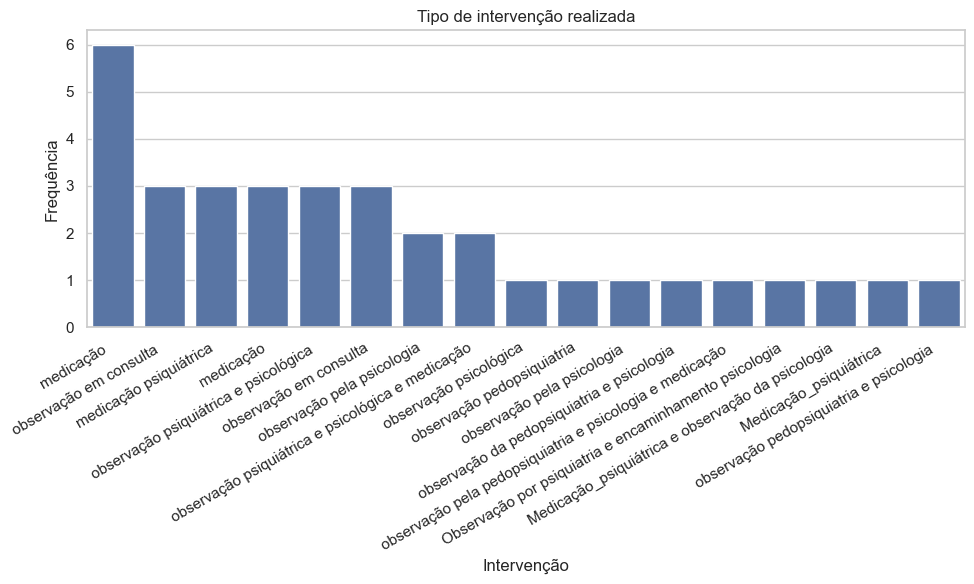

In [12]:
# ============================================================
# 7.4) 2.4 AVALIAÇÃO PEDOPSIQUIÁTRICA
# ============================================================

print("=== 2.4 Avaliação Pedopsiquiátrica ===")

# diagnóstico psiquiátrico
if diagnostico_psiquiatrico_col and diagnostico_psiquiatrico_col in df.columns:
    diag_table = freq_table(df[diagnostico_psiquiatrico_col])
    display(diag_table)
    plot_bar(
        df[diagnostico_psiquiatrico_col],
        "Diagnóstico psiquiátrico",
        xlabel="Diagnóstico",
        rotate=30,
        order=df[diagnostico_psiquiatrico_col].value_counts().index
    )
else:
    print("Não existe uma coluna clara de 'Diagnóstico psiquiátrico' no dataset. Esta parte ficou assinalada para revisão.")

# tipo de intervenção
if vars_map["intervencao"] in df.columns:
    interv_table = freq_table(df[vars_map["intervencao"]])
    display(interv_table)
    plot_bar(
        df[vars_map["intervencao"]],
        "Tipo de intervenção realizada",
        xlabel="Intervenção",
        rotate=30,
        order=df[vars_map["intervencao"]].value_counts().index
    )
else:
    print("Não foi encontrada a variável de intervenção.")

In [13]:
# ============================================================
# 8) 3. ANÁLISE DO SEGUIMENTO PÓS-ALTA
# ============================================================

print("=== 3. Seguimento Pós-Alta ===")

=== 3. Seguimento Pós-Alta ===


=== 3.1 Continuidade de Acompanhamento ===


,n,%
Seguimento psic após alta,,
Sim,28,73.7
Não,10,26.3


Não existe uma coluna clara de 'Tipo de seguimento' no dataset.

Valores observados em 'Duração do seguimento':


,n
Duração do seguimento,
mantem seguimento (última consulta 12/01/2026),2
sem seguimento,2
sem seguimento (faleceu),2
sem seguimento,2
mantém seguimento (última consulta a 10 de outubro de 2025),1
mantem seguimento no HBA e no psicologo privado,1
alta a 29/09/2025,1
mantem seguimento (última consula 16 de setembro),1
Sem seguimento,1


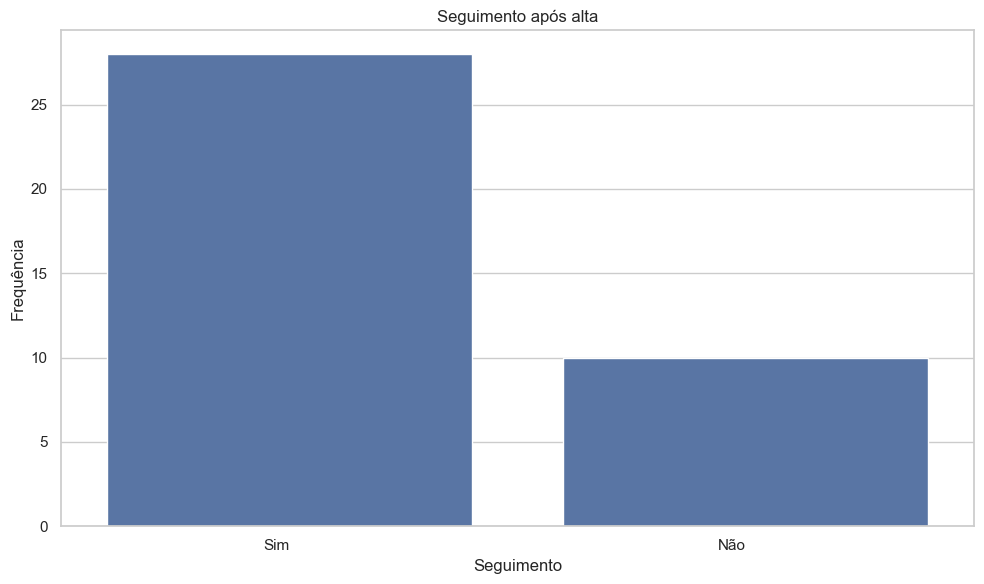

In [14]:
# ============================================================
# 8.1) 3.1 CONTINUIDADE DE ACOMPANHAMENTO
# ============================================================

print("=== 3.1 Continuidade de Acompanhamento ===")

# seguimento sim/não
seg_table = freq_table(df[vars_map["seguimento"]])
display(seg_table)

# tipo de seguimento
if tipo_seguimento_col and tipo_seguimento_col in df.columns:
    tipo_seg_table = freq_table(df[tipo_seguimento_col])
    display(tipo_seg_table)
    plot_bar(
        df[tipo_seguimento_col],
        "Tipo de seguimento após alta",
        xlabel="Tipo de seguimento",
        rotate=30
    )
else:
    print("Não existe uma coluna clara de 'Tipo de seguimento' no dataset.")

# duração do seguimento
# esta variável está em texto livre, então aqui faremos apenas descrição bruta
if vars_map["duracao_seguimento"] in df.columns:
    print("\nValores observados em 'Duração do seguimento':")
    display(df[vars_map["duracao_seguimento"]].value_counts(dropna=False).to_frame("n"))

# gráficos
plot_bar(df[vars_map["seguimento"]], "Seguimento após alta", xlabel="Seguimento")

=== 3.2 Comparação entre doentes com e sem seguimento ===


,Variável,Tipo,Teste,p,Interpretação
0,Idade,Contínua,Mann-Whitney,0.1609,Não significativo
1,Tempo_total_UCIP_dias,Contínua,Mann-Whitney,0.0033,Significativo
2,Sexo,Categórica,Exato de Fisher,0.1435,Não significativo
3,Doença psiquiátrica prévia,Categórica,Exato de Fisher,0.2685,Não significativo
4,Grupo clínico,Categórica,Qui-quadrado,0.2516,Não significativo
5,Ventilação,Categórica,Exato de Fisher,0.2251,Não significativo


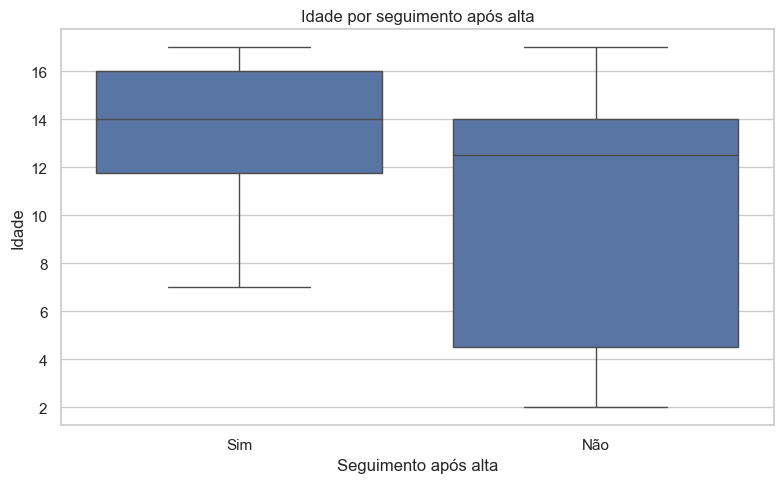

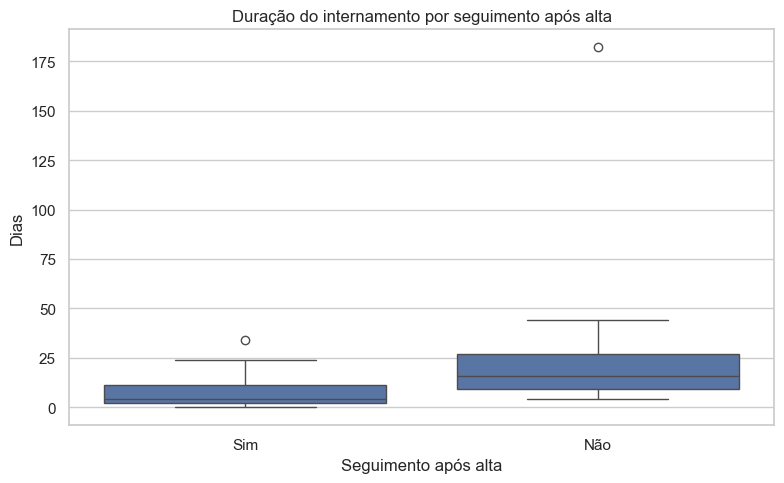

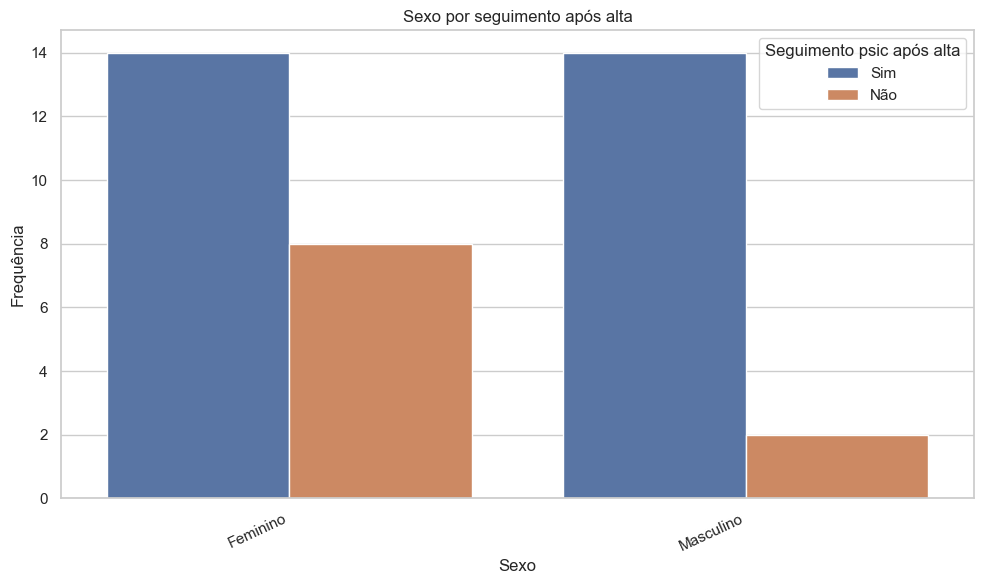

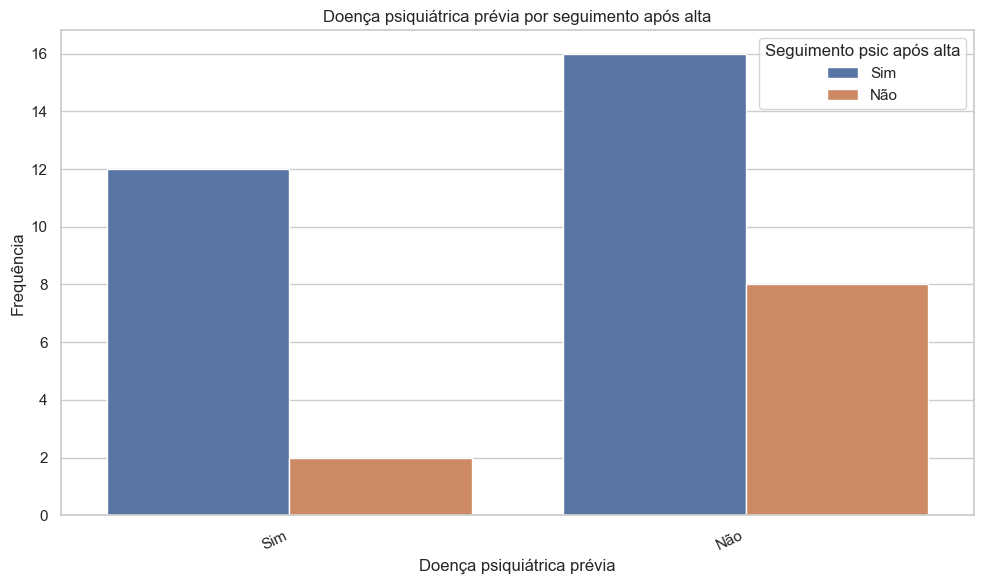

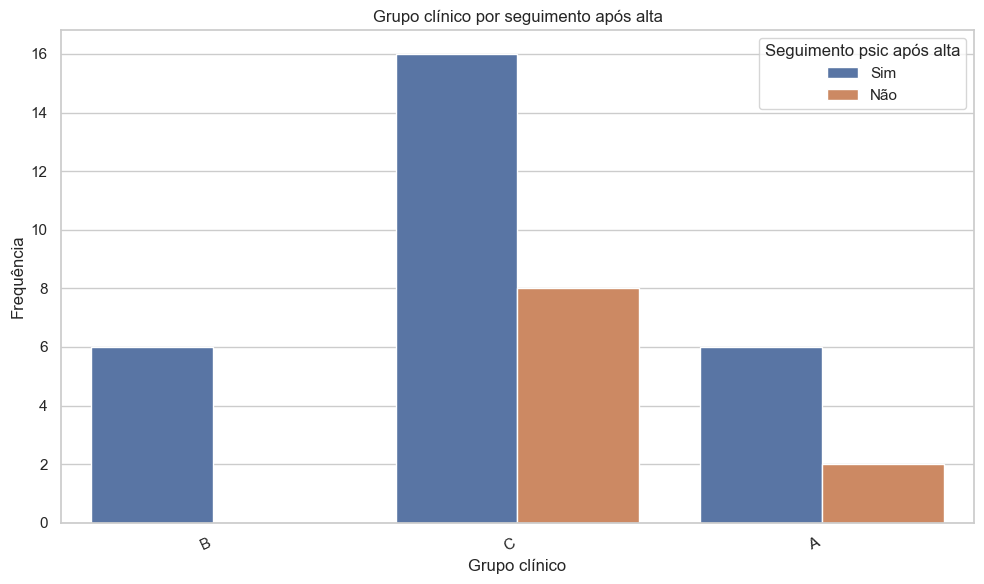

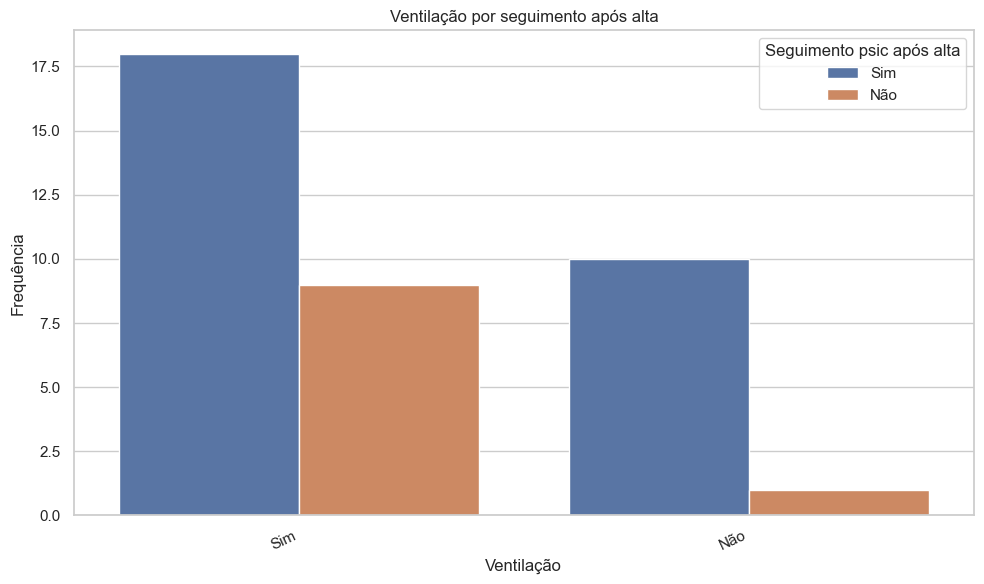

In [15]:
# ============================================================
# 8.2) 3.2 COMPARAÇÃO ENTRE DOENTES COM E SEM SEGUIMENTO
# ============================================================

print("=== 3.2 Comparação entre doentes com e sem seguimento ===")

comparison_results_followup = []

# variáveis contínuas
for var in ["Idade", "Tempo_total_UCIP_dias"]:
    if var in df.columns:
        res = compare_continuous_2groups(df, var, "Seguimento psic após alta")
        comparison_results_followup.append({
            "Variável": var,
            "Tipo": "Contínua",
            "Teste": res.get("teste"),
            "p": res.get("p"),
            "Interpretação": significance_label(res.get("p"))
        })

# variáveis categóricas
categorical_vars_followup = [
    "Sexo",
    "Doença psiquiátrica prévia",
    "Grupo clínico",
    "Ventilação"
]

# diagnóstico psiquiátrico só se existir
if diagnostico_psiquiatrico_col and diagnostico_psiquiatrico_col in df.columns:
    categorical_vars_followup.append(diagnostico_psiquiatrico_col)

for var in categorical_vars_followup:
    if var in df.columns:
        res = compare_categorical_2groups(df, var, "Seguimento psic após alta")
        comparison_results_followup.append({
            "Variável": var,
            "Tipo": "Categórica",
            "Teste": res.get("teste"),
            "p": res.get("p"),
            "Interpretação": significance_label(res.get("p"))
        })

comparison_results_followup_df = pd.DataFrame(comparison_results_followup)
display(comparison_results_followup_df)

# gráficos comparativos
# idade
tmp = df[[vars_map["idade"], vars_map["seguimento"]]].dropna()
plt.figure(figsize=(8,5))
sns.boxplot(data=tmp, x=vars_map["seguimento"], y=vars_map["idade"])
plt.title("Idade por seguimento após alta")
plt.xlabel("Seguimento após alta")
plt.ylabel("Idade")
plt.tight_layout()
plt.show()

# duração internamento
tmp = df[[vars_map["duracao_internamento"], vars_map["seguimento"]]].dropna()
plt.figure(figsize=(8,5))
sns.boxplot(data=tmp, x=vars_map["seguimento"], y=vars_map["duracao_internamento"])
plt.title("Duração do internamento por seguimento após alta")
plt.xlabel("Seguimento após alta")
plt.ylabel("Dias")
plt.tight_layout()
plt.show()

# categóricas
for var in ["Sexo", "Doença psiquiátrica prévia", "Grupo clínico", "Ventilação"]:
    if var in df.columns:
        plot_grouped_bar(df, vars_map["seguimento"], var, f"{var} por seguimento após alta", rotate=25)

In [16]:
# ============================================================
# 9) 4. ANÁLISE DOS GRUPOS CLÍNICOS A, B E C
# ============================================================

print("=== 4. Análise dos Grupos Clínicos A, B e C ===")

=== 4. Análise dos Grupos Clínicos A, B e C ===


,n,%
Grupo clínico,,
C,24,63.2
A,8,21.1
B,6,15.8


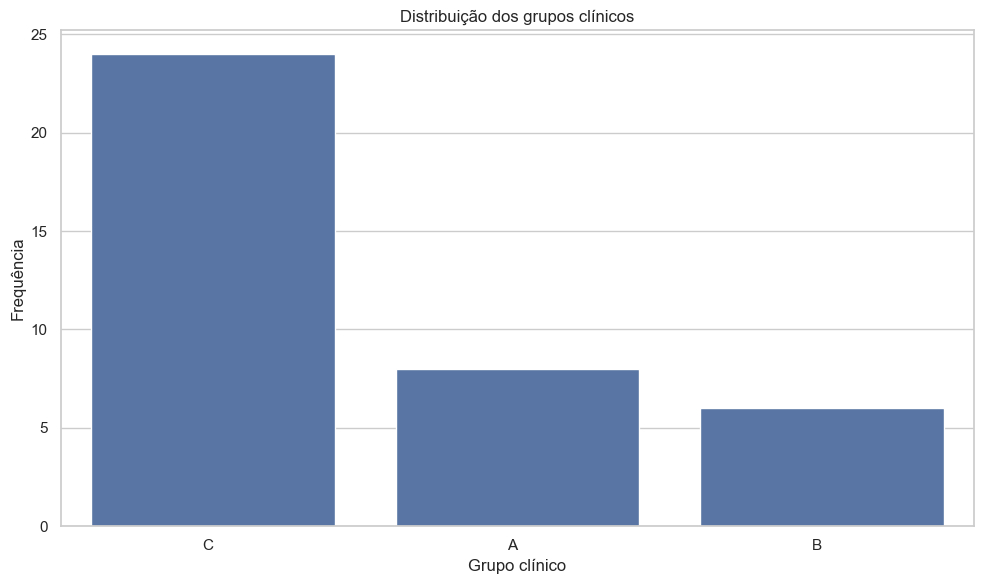

In [17]:
# ============================================================
# 9.1) 4.1 DISTRIBUIÇÃO DOS GRUPOS
# ============================================================

grupo_table = freq_table(df["Grupo clínico"])
display(grupo_table)

plot_bar(df["Grupo clínico"], "Distribuição dos grupos clínicos", xlabel="Grupo clínico")

=== 4.2 Comparação entre grupos ===


,Variável,Tipo,Teste,p,Interpretação
0,Idade,Contínua,Kruskal-Wallis,0.0656,Não significativo
1,Tempo_total_UCIP_dias,Contínua,Kruskal-Wallis,0.0092,Significativo
2,Sexo,Categórica,Qui-quadrado,0.1055,Não significativo
3,Ventilação,Categórica,Qui-quadrado,0.7701,Não significativo
4,Seguimento psic após alta,Categórica,Qui-quadrado,0.2516,Não significativo


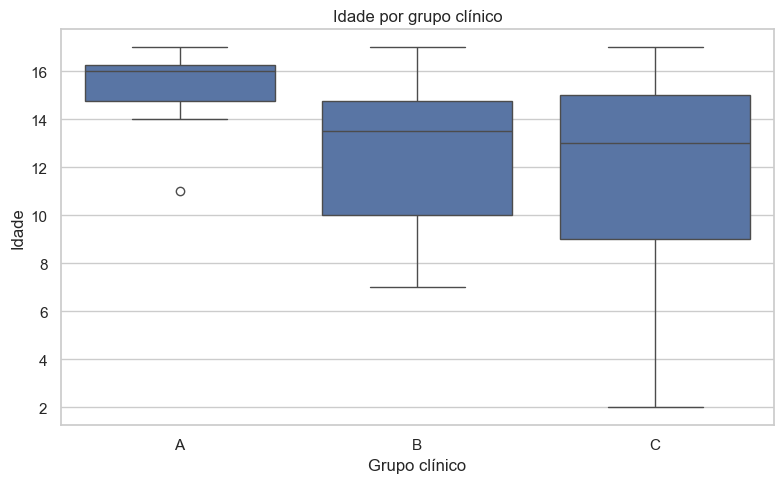

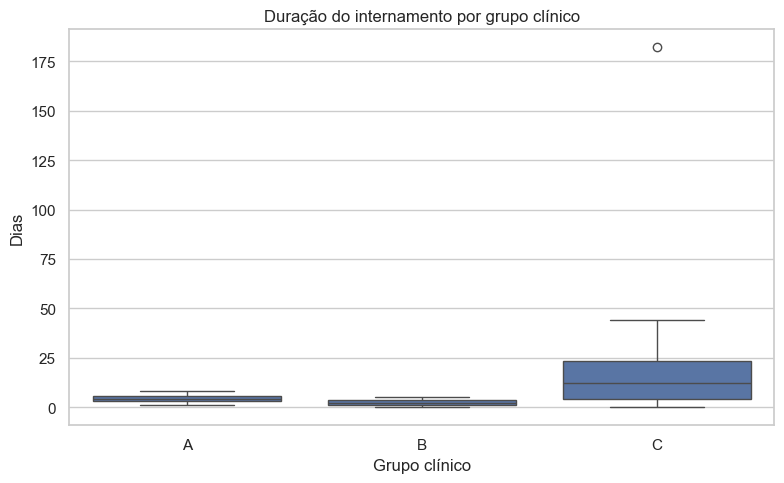

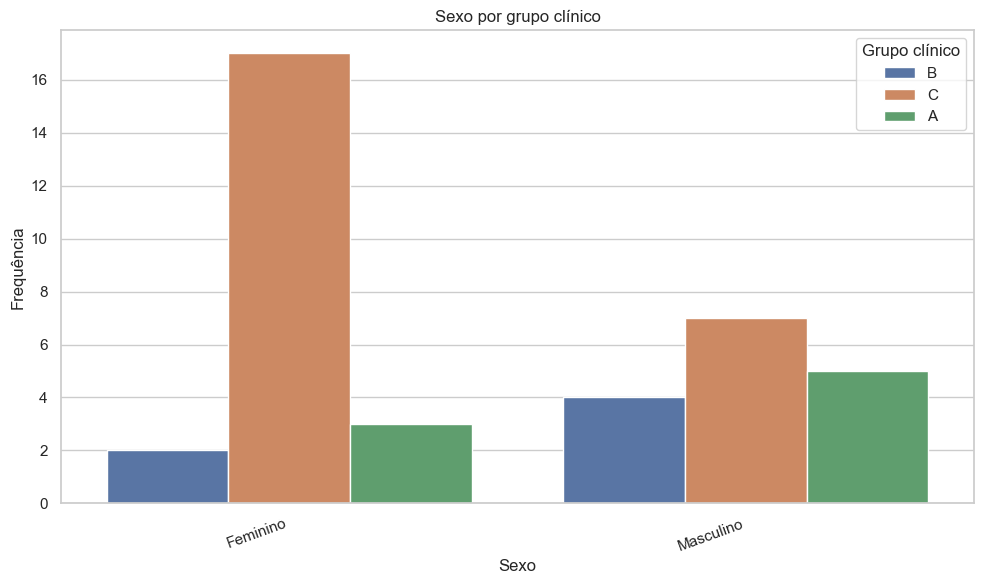

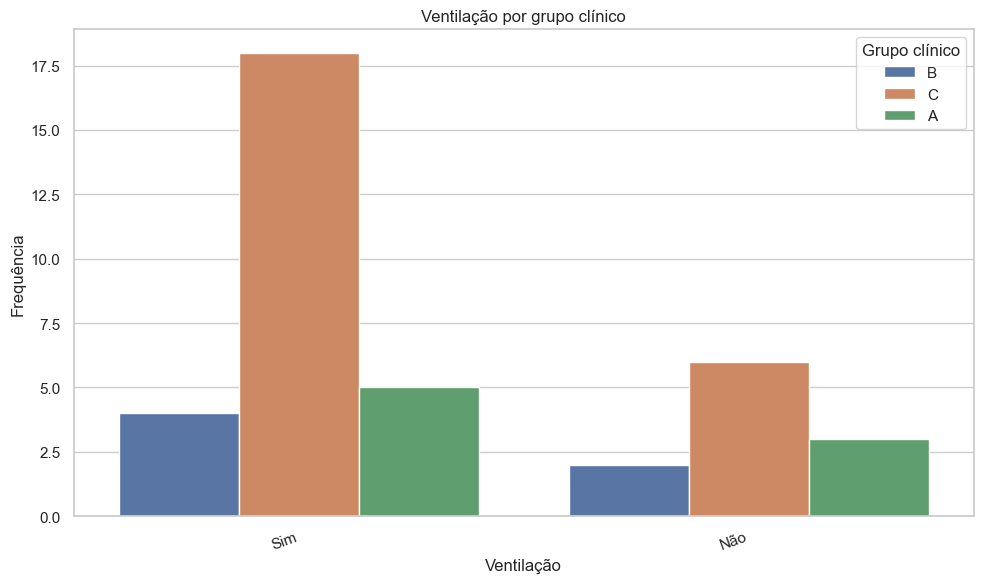

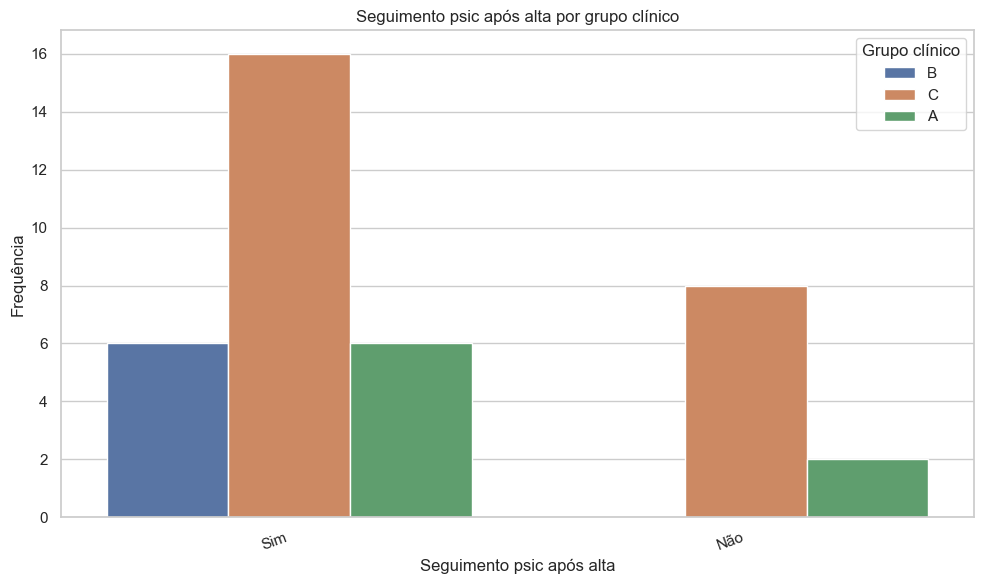

In [18]:
# ============================================================
# 9.2) 4.2 COMPARAÇÃO ENTRE GRUPOS
# ============================================================

print("=== 4.2 Comparação entre grupos ===")

comparison_results_groups = []

# contínuas
for var in ["Idade", "Tempo_total_UCIP_dias"]:
    if var in df.columns:
        res = compare_continuous_3groups(df, var, "Grupo clínico")
        comparison_results_groups.append({
            "Variável": var,
            "Tipo": "Contínua",
            "Teste": res.get("teste"),
            "p": res.get("p"),
            "Interpretação": significance_label(res.get("p"))
        })

# categóricas
categorical_vars_groups = [
    "Sexo",
    "Ventilação",
    "Seguimento psic após alta"
]

if diagnostico_psiquiatrico_col and diagnostico_psiquiatrico_col in df.columns:
    categorical_vars_groups.append(diagnostico_psiquiatrico_col)

for var in categorical_vars_groups:
    if var in df.columns:
        res = compare_categorical_3groups(df, var, "Grupo clínico")
        comparison_results_groups.append({
            "Variável": var,
            "Tipo": "Categórica",
            "Teste": res.get("teste"),
            "p": res.get("p"),
            "Interpretação": significance_label(res.get("p"))
        })

comparison_results_groups_df = pd.DataFrame(comparison_results_groups)
display(comparison_results_groups_df)

# boxplots
tmp = df[["Grupo clínico", "Idade"]].dropna()
plt.figure(figsize=(8,5))
sns.boxplot(data=tmp, x="Grupo clínico", y="Idade", order=["A", "B", "C"])
plt.title("Idade por grupo clínico")
plt.xlabel("Grupo clínico")
plt.ylabel("Idade")
plt.tight_layout()
plt.show()

tmp = df[["Grupo clínico", "Tempo_total_UCIP_dias"]].dropna()
plt.figure(figsize=(8,5))
sns.boxplot(data=tmp, x="Grupo clínico", y="Tempo_total_UCIP_dias", order=["A", "B", "C"])
plt.title("Duração do internamento por grupo clínico")
plt.xlabel("Grupo clínico")
plt.ylabel("Dias")
plt.tight_layout()
plt.show()

# barras agrupadas
for var in ["Sexo", "Ventilação", "Seguimento psic após alta"]:
    if var in df.columns:
        plot_grouped_bar(df, "Grupo clínico", var, f"{var} por grupo clínico", rotate=20)

In [19]:
# ============================================================
# 10) TABELA FINAL DE SUMÁRIOS DESCRITIVOS
# ============================================================

print("=== Sumário descritivo principal ===")

summary_rows = []

for col in ["Idade", "Tempo_total_UCIP_dias", "Dias de ventilação", "Dias de sedoanalgesia"]:
    if col in df.columns:
        summary_rows.append(continuous_summary(df[col], col))

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

print("\nVariáveis categóricas principais:")
for col in [
    "Sexo",
    "Doença psiquiátrica prévia",
    "Doença crónica prévia_bin",
    "Categoria_diagnóstico",
    "Ventilação",
    "Seguimento psic após alta",
    "Grupo clínico"
]:
    if col in df.columns:
        print(f"\n--- {col} ---")
        display(freq_table(df[col]))

=== Sumário descritivo principal ===


,variável,n,normalidade_p,distribuição,resumo,mín,máx
0,Idade,38,0.0002,Não normal,14.00 (11.00-16.00),2.0,17.0
1,Tempo_total_UCIP_dias,38,0.0000,Não normal,5.50 (3.00-14.25),0.0,182.0
2,Dias de ventilação,37,0.0000,Não normal,2.00 (0.00-12.00),0.0,85.0
3,Dias de sedoanalgesia,38,0.0000,Não normal,5.00 (2.25-17.25),0.0,152.0



Variáveis categóricas principais:

--- Sexo ---


,n,%
Sexo,,
Feminino,22,57.9
Masculino,16,42.1



--- Doença psiquiátrica prévia ---


...

,n,%
Ventilação,,
Sim,27,71.1
Não,11,28.9



--- Seguimento psic após alta ---


,n,%
Seguimento psic após alta,,
Sim,28,73.7
Não,10,26.3



--- Grupo clínico ---


,n,%
Grupo clínico,,
C,24,63.2
A,8,21.1
B,6,15.8
